# Faraday's law -- induced EMF is the calculus of changing flux
### one rule, $\varepsilon=-\dfrac{d\Phi}{dt}$, behind transformers, generators, and brakes

A changing magnetic flux through a loop drives a voltage:
$$\varepsilon=-\frac{d\Phi}{dt},\qquad \Phi=\int\mathbf B\cdot d\mathbf a.$$
The minus sign is **Lenz's law** (the induced current opposes the change). The flux
can change three ways -- a changing field, a moving loop, or a rotating loop -- and
all three are the *same* derivative. This notebook explores each, computing the EMF
**numerically** (a finite-difference derivative) and checking it against the exact
calculus. The companion `scripts/faraday_emf.c` does the same `-dPhi/dt` in ~20 lines
of C. Civilian education.

In [1]:
import numpy as np, matplotlib.pyplot as plt
import sympy as sp
import sys, pathlib
sys.path.insert(0, str(pathlib.Path.cwd().parent))
from griffiths import electrodynamics as ed
from dgs import numerical_methods as nm
sp.init_printing()
print("ready")

ready


## 1. Transformer EMF -- a changing field through a fixed loop

Hold a loop (area $A$) still in a field $B(t)=B_0\sin\omega t$. The flux is
$\Phi=B_0 A\sin\omega t$, so
$$\varepsilon=-\frac{d\Phi}{dt}=-B_0 A\omega\cos\omega t.$$
SymPy takes the derivative; the numerical $-d\Phi/dt$ from samples lands on it. Note
the EMF **leads the flux by 90 degrees** -- the derivative of a sine is a cosine.

Phi(t) =


emf = -dPhi/dt =


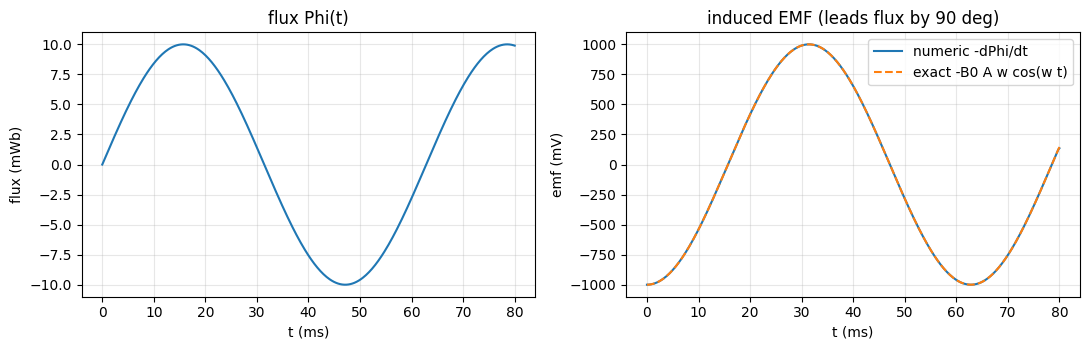

max |numeric - exact| = 6.699858751335608e-05 V  (same as the C program)


In [2]:
t = sp.Symbol("t"); B0, A, w = 1.0, 0.01, 100.0
Phi_sym = B0 * A * sp.sin(w * t)
emf_sym = ed.induced_emf(Phi_sym, t)            # -dPhi/dt, symbolic
print("Phi(t) ="); display(Phi_sym)
print("emf = -dPhi/dt ="); display(emf_sym)

tt = np.linspace(0, 0.08, 400)
Phi = B0 * A * np.sin(w * tt)
emf_num = -nm.gradient(Phi, tt)                 # numerical -dPhi/dt
emf_exact = -B0 * A * w * np.cos(w * tt)
fig, ax = plt.subplots(1, 2, figsize=(11, 3.6))
ax[0].plot(tt*1e3, Phi*1e3); ax[0].set(xlabel="t (ms)", ylabel="flux (mWb)", title="flux Phi(t)")
ax[1].plot(tt*1e3, emf_num*1e3, label="numeric -dPhi/dt")
ax[1].plot(tt*1e3, emf_exact*1e3, "--", label="exact -B0 A w cos(w t)")
ax[1].set(xlabel="t (ms)", ylabel="emf (mV)", title="induced EMF (leads flux by 90 deg)"); ax[1].legend()
for a in ax: a.grid(alpha=0.3)
plt.tight_layout(); plt.show()
print("max |numeric - exact| =", np.max(np.abs(emf_num-emf_exact)[3:-3]), "V  (same as the C program)")

## 2. Lenz's law -- the sign that opposes the change

Through a resistance $R$ the EMF drives a current $I=\varepsilon/R$. The minus sign
means the induced current makes its **own** flux opposing the change in $\Phi$:
when the flux rises the current fights to lower it, and vice versa. That is why
induction is a **brake** (and why energy is conserved -- no free current).

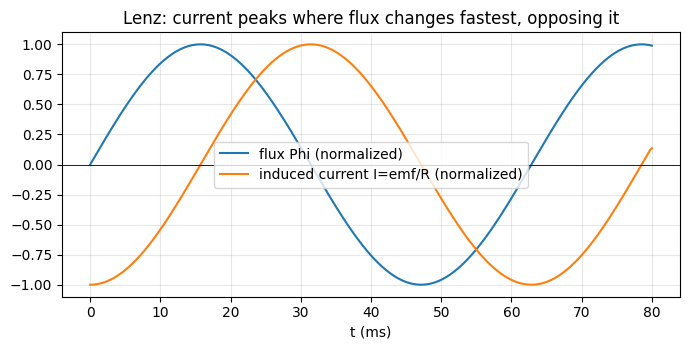

when Phi is rising fastest (Phi=0), |I| is largest and signed to oppose the rise


In [3]:
R = 5.0
I = emf_num / R
plt.figure(figsize=(7, 3.6))
plt.plot(tt*1e3, Phi/Phi.max(), label="flux Phi (normalized)")
plt.plot(tt*1e3, I/np.abs(I).max(), label="induced current I=emf/R (normalized)")
plt.axhline(0, color="k", lw=0.6)
plt.xlabel("t (ms)"); plt.legend(); plt.title("Lenz: current peaks where flux changes fastest, opposing it")
plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("when Phi is rising fastest (Phi=0), |I| is largest and signed to oppose the rise")

## 3. Motional EMF -- a moving loop in a steady field

Now keep $B$ constant and **move** the loop: a bar of length $\ell$ sliding at speed
$v$ sweeps area, so $\Phi=B\ell x$ and $\varepsilon=-d\Phi/dt=-B\ell v$. Same law,
different reason for the flux change -- this is the generator/eddy-brake EMF
(`motional_emf`), the basis of the falling-loop Problem 7.11.

In [4]:
B, ell = 0.5, 0.2
for v in (1.0, 2.0, 3.0):
    print(f"  v={v} m/s :  emf = B*ell*v = {ed.motional_emf(B, ell, v):.3f} V")
# energy view: the mechanical power F*v = emf^2/R is dissipated in the resistor
v = 3.0; emf = ed.motional_emf(B, ell, v); print(f"\nat v={v}: power to R(5 ohm) = emf^2/R = {emf**2/5:.4f} W (came from whoever pushes the bar)")

  v=1.0 m/s :  emf = B*ell*v = 0.100 V
  v=2.0 m/s :  emf = B*ell*v = 0.200 V
  v=3.0 m/s :  emf = B*ell*v = 0.300 V

at v=3.0: power to R(5 ohm) = emf^2/R = 0.0180 W (came from whoever pushes the bar)


## 4. Rotating loop -- the AC generator (and motor, run backwards)

Spin a loop (N turns, area $A$) at angular speed $\omega$ in a steady field: the
flux is $\Phi=NBA\cos\omega t$, so
$$\varepsilon=-\frac{d\Phi}{dt}=NBA\omega\sin\omega t.$$
A steady rotation gives a **sinusoidal voltage** -- this is exactly how every AC
generator works, and a motor is the same machine driven in reverse.

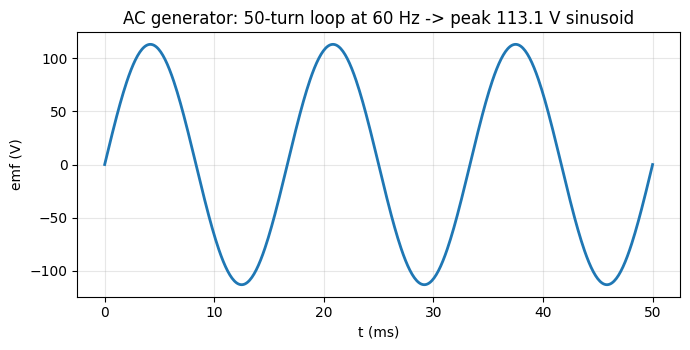

peak EMF = N B A omega = 113.10 V at 60 Hz


In [5]:
N, B, A, w = 50, 0.3, 0.02, 2*np.pi*60      # 60 Hz
tt = np.linspace(0, 0.05, 500)
Phi = N*B*A*np.cos(w*tt)
emf = N*B*A*w*np.sin(w*tt)                    # = -dPhi/dt
plt.figure(figsize=(7, 3.6))
plt.plot(tt*1e3, emf, lw=2)
plt.xlabel("t (ms)"); plt.ylabel("emf (V)"); plt.grid(alpha=0.3)
plt.title(f"AC generator: {N}-turn loop at 60 Hz -> peak {N*B*A*w:.1f} V sinusoid")
plt.tight_layout(); plt.show()
print(f"peak EMF = N B A omega = {N*B*A*w:.2f} V at 60 Hz")

## What ties it together

All three are one equation, $\varepsilon=-d\Phi/dt$:

| flux changes because... | example | EMF |
|---|---|---|
| the **field** changes | transformer | $-B_0A\omega\cos\omega t$ |
| the **loop moves** | sliding bar / eddy brake | $-B\ell v$ |
| the **loop rotates** | AC generator / motor | $NBA\omega\sin\omega t$ |

The physics *is* the derivative: induced EMF is the rate of change of flux, sign-
flipped by Lenz. We computed it three ways -- SymPy (exact), NumPy finite differences,
and ~20 lines of C (`scripts/faraday_emf.c`) -- and they all agree. Electricity and
magnetism meet calculus here, and this single law runs the world's motors and
generators. Civilian education.